###### 131_2_practical_extract_check_csv_answer.ipynb

In [1]:
#cell1
import pandas as pd
import re
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", None)
plt.rcParams["font.family"] = "Meiryo"

In [4]:
df_defect = pd.read_csv("dataset/defect_comment.csv")
df_defect

,site,model,defect_id,comment
0,SUS,J69P,D-001,2026/06/01にKLAK-67890で1件発生。160V条件で確認。
1,SUS,J69P,D-002,2026/06/03にKLAK-67890とLCM-220を確認。再発の可能性あり。
2,SUS,J69P,D-003,Buck-IC周辺を確認。KLBC-12345で焼損痕あり。
3,WSE,310D,D-004,2026/06/04にLCM-220で2件発生。140V検査では検出せず。
4,WSE,310D,D-005,温度85C条件でCAN-330の1件を確認。
5,GSE,J69P,D-006,2026/06/05にCAN-330で1件再発。12V条件で確認。
6,GSE,J69P,D-007,CAN-330とKLAK-67890を同時に確認。
7,MELMB,310D,D-008,現象再現せず。対象品番KLEE-55555は継続確認中。
8,MELMB,310D,D-009,PY-110相当品で1件確認。160V条件で確認。
9,MELMB,310D,D-010,コメントのみ。対象品番の記載なし。


In [5]:
selected_df = df_defect.set_index("defect_id")["comment"].str.extractall(
    r"([A-Z]{2,}-\d{3,})",
    flags=re.IGNORECASE,
)
selected_df

0
defect_id match            
D-001     0      KLAK-67890
D-002     0      KLAK-67890
          1         LCM-220
D-003     0      KLBC-12345
D-004     0         LCM-220
D-005     0         CAN-330
D-006     0         CAN-330
D-007     0         CAN-330
          1      KLAK-67890
D-008     0      KLEE-55555
D-009     0          PY-110

In [6]:
#cell4
selected_df = selected_df.rename(
    columns={
        0:"part_code",
    }
)
selected_df

part_code
defect_id match            
D-001     0      KLAK-67890
D-002     0      KLAK-67890
          1         LCM-220
D-003     0      KLBC-12345
D-004     0         LCM-220
D-005     0         CAN-330
D-006     0         CAN-330
D-007     0         CAN-330
          1      KLAK-67890
D-008     0      KLEE-55555
D-009     0          PY-110

In [7]:
df_parts = selected_df.reset_index()
df_parts

,defect_id,match,part_code
0,D-001,0,KLAK-67890
1,D-002,0,KLAK-67890
2,D-002,1,LCM-220
3,D-003,0,KLBC-12345
4,D-004,0,LCM-220
5,D-005,0,CAN-330
6,D-006,0,CAN-330
7,D-007,0,CAN-330
8,D-007,1,KLAK-67890
9,D-008,0,KLEE-55555


In [11]:
#cell6

df_extract_count = df_parts.groupby(
    "defect_id",
    as_index=False,
)["part_code"].count()
#df_extra_count

df_extract_count = df_extra_count.rename(
    columns={
        "part_code": "part_code_count",
    }
)
df_extract_count

,defect_id,part_code_count
0,D-001,1
1,D-002,2
2,D-003,1
3,D-004,1
4,D-005,1
5,D-006,1
6,D-007,2
7,D-008,1
8,D-009,1


In [13]:
#cell7

df_defect_check = pd.merge(
    df_defect,
    df_extract_count,
    on="defect_id",
    how="left",
)
df_defect_check.head(3)

,site,model,defect_id,comment,part_code_count
0,SUS,J69P,D-001,2026/06/01にKLAK-67890で1件発生。160V条件で確認。,1.0
1,SUS,J69P,D-002,2026/06/03にKLAK-67890とLCM-220を確認。再発の可能性あり。,2.0
2,SUS,J69P,D-003,Buck-IC周辺を確認。KLBC-12345で焼損痕あり。,1.0


In [16]:
df_defect_check["part_code_count"] = df_defect_check["part_code_count"].fillna(0)
df_defect_check
df_defect_check["part_code_count"] = df_defect_check["part_code_count"].astype(int)
df_defect_check

,site,model,defect_id,comment,part_code_count
0,SUS,J69P,D-001,2026/06/01にKLAK-67890で1件発生。160V条件で確認。,1
1,SUS,J69P,D-002,2026/06/03にKLAK-67890とLCM-220を確認。再発の可能性あり。,2
2,SUS,J69P,D-003,Buck-IC周辺を確認。KLBC-12345で焼損痕あり。,1
3,WSE,310D,D-004,2026/06/04にLCM-220で2件発生。140V検査では検出せず。,1
4,WSE,310D,D-005,温度85C条件でCAN-330の1件を確認。,1
5,GSE,J69P,D-006,2026/06/05にCAN-330で1件再発。12V条件で確認。,1
6,GSE,J69P,D-007,CAN-330とKLAK-67890を同時に確認。,2
7,MELMB,310D,D-008,現象再現せず。対象品番KLEE-55555は継続確認中。,1
8,MELMB,310D,D-009,PY-110相当品で1件確認。160V条件で確認。,1
9,MELMB,310D,D-010,コメントのみ。対象品番の記載なし。,0


In [20]:
#cell9
df_defect_check["extract_result"] = "OK"
df_defect_check

df_defect_check.loc[
    df_defect_check["part_code_count"] == 0,
    "extract_result",
] = "要確認"
df_defect_check

,site,model,defect_id,comment,part_code_count,extract_result
0,SUS,J69P,D-001,2026/06/01にKLAK-67890で1件発生。160V条件で確認。,1,OK
1,SUS,J69P,D-002,2026/06/03にKLAK-67890とLCM-220を確認。再発の可能性あり。,2,OK
2,SUS,J69P,D-003,Buck-IC周辺を確認。KLBC-12345で焼損痕あり。,1,OK
3,WSE,310D,D-004,2026/06/04にLCM-220で2件発生。140V検査では検出せず。,1,OK
4,WSE,310D,D-005,温度85C条件でCAN-330の1件を確認。,1,OK
5,GSE,J69P,D-006,2026/06/05にCAN-330で1件再発。12V条件で確認。,1,OK
6,GSE,J69P,D-007,CAN-330とKLAK-67890を同時に確認。,2,OK
7,MELMB,310D,D-008,現象再現せず。対象品番KLEE-55555は継続確認中。,1,OK
8,MELMB,310D,D-009,PY-110相当品で1件確認。160V条件で確認。,1,OK
9,MELMB,310D,D-010,コメントのみ。対象品番の記載なし。,0,要確認


In [22]:
#cell10
df_extract_ng = df_defect_check[
    df_defect_check["extract_result"] == "要注意"
].copy()
df_extract_ng

,site,model,defect_id,comment,part_code_count,extract_result


In [25]:
#cell 11
df_check_summary = df_defect_check.groupby(
    [
        "site",
        "extract_result",
    ],
    as_index=False,
)["defect_id"].count()
df_check_summary

df_check_summary = df_check_summary.rename(
    columns={
        "defect_id": "count",
    }
)
df_check_summary

,site,extract_result,count
0,GSE,OK,2
1,MELMB,OK,2
2,MELMB,要確認,1
3,SUS,OK,3
4,WSE,OK,2


In [26]:
#cell 12
df_total_count = df_defect_check.groupby(
    "site",
    as_index=False,
)["defect_id"].count()

df_total_count = df_total_count.rename(
    columns={
        "defect_id": "total_count",
    }
)
df_total_count

,site,total_count
0,GSE,2
1,MELMB,3
2,SUS,3
3,WSE,2


In [29]:
df_ok_count = df_defect_check[
    df_defect_check["extract_result"] == "OK"
].groupby(
    "site",
    as_index=False,
)["defect_id"].count()
#df_ok_count
df_ok_count = df_ok_count.rename(
    columns={
        "defect_id": "ok_count",
    }
)
df_ok_count

,site,ok_count
0,GSE,2
1,MELMB,2
2,SUS,3
3,WSE,2


In [34]:
#cell 14
df_ok_rate = pd.merge(
    df_total_count,
    df_ok_count,
    on="site",
    how="left"
)

df_ok_rate["ok_count"] = df_ok_rate["ok_count"].fillna(0)
df_ok_rate["ok_count"] = df_ok_rate["ok_count"].astype(int)

df_ok_rate["ok_rate"] = (
    df_ok_rate["ok_count"]
    / df_ok_rate["total_count"]
    * 100
)

df_ok_rate = df_ok_rate.sort_values(
    "ok_rate",
    ascending=False,
).reset_index(drop=True)
df_ok_rate

,site,total_count,ok_count,ok_rate
0,GSE,2,2,100.000000
1,SUS,3,3,100.000000
2,WSE,2,2,100.000000
3,MELMB,3,2,66.666667


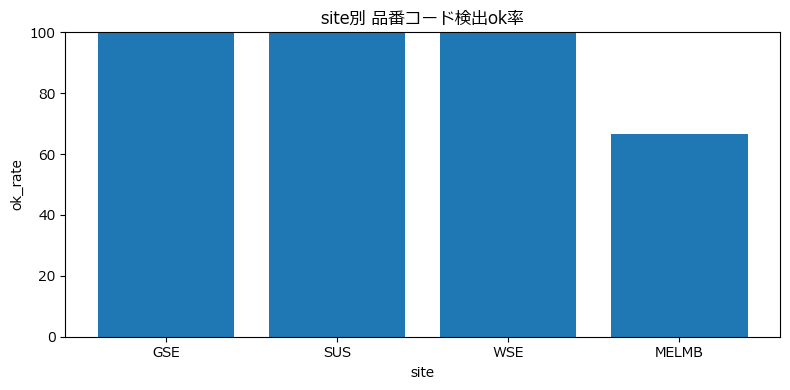

In [46]:
#cell15

plt.figure(figsize=(8, 4))

plt.bar(
    df_ok_rate["site"],
    df_ok_rate["ok_rate"],
)

plt.title("site別 品番コード検出ok率")
plt.xlabel("site")
plt.ylabel("ok_rate")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()